In [1]:
import pandas as pd

from src.configuration.config import set_seed
from src.AggregationBasedArchitecture.Logistic_Regression import LogReg_all_signals

In [2]:
BASE_SEED = 42
set_seed(BASE_SEED)

In [3]:
dfSimAgg = pd.read_csv("../data/aggregated/simAgg.csv")
dfSimAggNorm = pd.read_csv("../data/aggregated/simAggNorm.csv")
dfAdvAgg = pd.read_csv("../data/aggregated/advAgg.csv")
dfAdvAggNorm = pd.read_csv("../data/aggregated/advAggNorm.csv")

   Source  Accuracy      Loss  TP  TN  FP  FN
0    Art6  0.750000  0.544877   4   2   2   0
1   Bus14  0.562500  0.638095   8   1   2   5
2    Edu2  0.833333  0.525362  10   0   1   1
3    Ent5  0.666667  0.625475   5   3   1   3
4   Med15  0.529412  0.961367   4   5   7   1
5    Phi3  0.555556  0.750704   2   3   2   2
6    Pol2  0.500000  0.767996   7   2   6   3
7    Pol9  0.437500  0.825650   2   5   0   9
8  Tech10  0.266667  0.918625   0   4   0  11
9  Tech21  0.727273  0.674986   0   8   0   3
[[33 21]
 [38 42]]


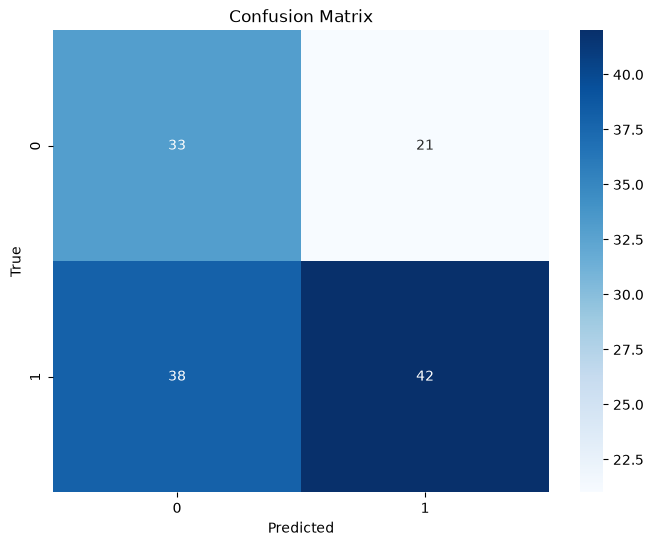

In [4]:
results = []
results = LogReg_all_signals(dfSimAgg, results, "Simple", False)

   Source  Accuracy      Loss  TP  TN  FP  FN
0    Art6  0.750000  0.740478   4   2   2   0
1   Bus14  0.500000  0.688224   7   1   2   6
2    Edu2  0.666667  0.638848   7   1   0   4
3    Ent5  0.500000  0.641382   4   2   2   4
4   Med15  0.705882  0.719156   4   8   4   1
5    Phi3  0.777778  0.584334   3   4   1   1
6    Pol2  0.444444  0.745081   5   3   5   5
7    Pol9  0.625000  0.632431   7   3   2   4
8  Tech10  0.666667  0.596820   7   3   1   4
9  Tech21  0.454545  0.763793   0   5   3   3
[[32 22]
 [32 48]]


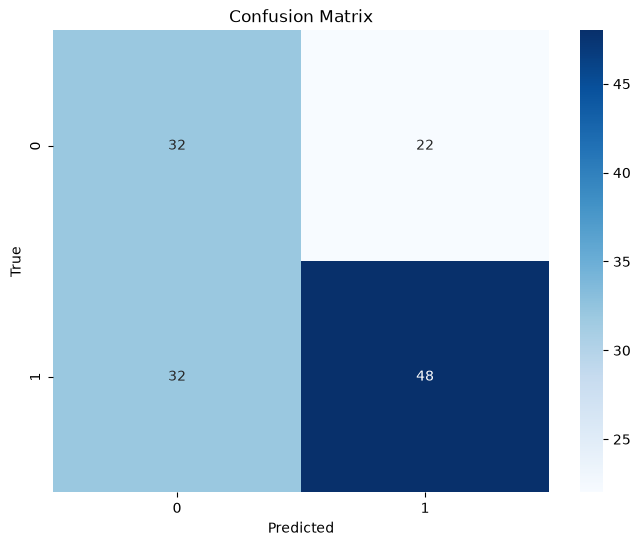

In [5]:
results = LogReg_all_signals(dfSimAggNorm, results, "Simple", True)

   Source  Accuracy      Loss  TP  TN  FP  FN
0    Art6  0.500000  0.866128   4   0   4   0
1   Bus14  0.437500  0.710930   6   1   2   7
2    Edu2  0.833333  0.492300  10   0   1   1
3    Ent5  0.583333  0.591484   5   2   2   3
4   Med15  0.411765  1.020884   4   3   9   1
5    Phi3  0.555556  0.678953   2   3   2   2
6    Pol2  0.555556  1.002570   9   1   7   1
7    Pol9  0.437500  0.943212   3   4   1   8
8  Tech10  0.266667  1.168793   0   4   0  11
9  Tech21  0.727273  0.672443   0   8   0   3
[[26 28]
 [37 43]]


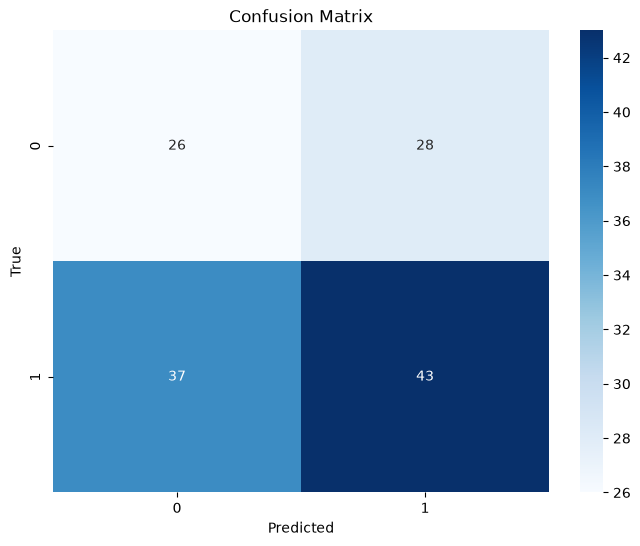

In [6]:
results = LogReg_all_signals(dfAdvAgg, results, "Advanced", False)

   Source  Accuracy      Loss  TP  TN  FP  FN
0    Art6  0.625000  0.674896   4   1   3   0
1   Bus14  0.750000  0.600537  10   2   1   3
2    Edu2  0.583333  0.698033   6   1   0   5
3    Ent5  0.500000  0.672521   5   1   3   3
4   Med15  0.588235  1.232263   5   5   7   0
5    Phi3  0.666667  0.470889   2   4   1   2
6    Pol2  0.500000  0.759528   7   2   6   3
7    Pol9  0.687500  0.916314   7   4   1   4
8  Tech10  0.333333  1.046919   3   2   2   8
9  Tech21  0.636364  0.698709   1   6   2   2
[[28 26]
 [30 50]]


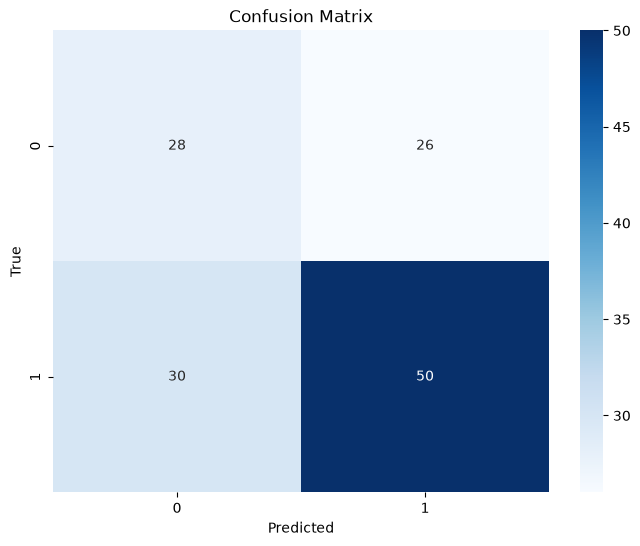

In [7]:
results = LogReg_all_signals(dfAdvAggNorm, results, "Advanced", True)

In [8]:
summary = pd.DataFrame(results)
summary["macro_f1"] = (summary["f1_0"] + summary["f1_1"]) / 2

summary = summary.sort_values("Accuracy (Balanced)", ascending=False).round(3)

In [9]:
summary

,Aggregation,Normalized,Accuracy (Balanced),Loss,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_f1
1,Simple,True,0.596,0.677,0.500,0.686,0.593,0.600,0.542,0.640,0.591
3,Advanced,True,0.572,0.809,0.483,0.658,0.519,0.625,0.500,0.641,0.571
0,Simple,False,0.568,0.744,0.465,0.667,0.611,0.525,0.528,0.587,0.558
2,Advanced,False,0.509,0.842,0.413,0.606,0.481,0.538,0.444,0.570,0.507
